In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import random
import scipy as sp

import torch
from torch import nn, optim
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import sys
print(sys.executable)
import os
print(os.getcwd())

from pathlib import Path

/Users/owenyi/Desktop/Code_Projects/Python/ML_and_reinforcement/.venv/bin/python
/Users/owenyi/Desktop/Code_Projects/Python/ML_and_reinforcement/joint_embedding


In [2]:
DATASET_PATH = Path("../datasets/data")
assert DATASET_PATH.exists()

In [3]:
dataset = torchvision.datasets.MNIST(
    root=DATASET_PATH,
    download=True,
)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

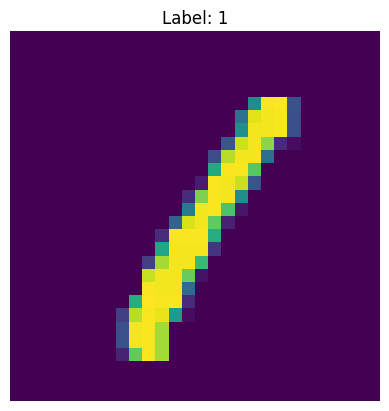

In [4]:
img, label = dataset[3]

# Display
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')

Text(0.5, 1.0, 'Augmented')

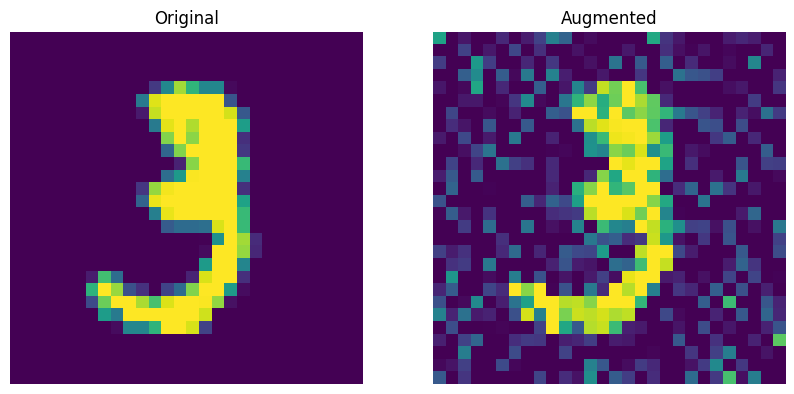

In [5]:
img_size = 224

class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1, clamp=True):
        self.mean = mean
        self.std = std
        self.clamp = clamp  # keep values in valid range

    def __call__(self, img):
        """
        img: Tensor of shape (C, H, W), typically in [0, 1]
        """
        if not torch.is_tensor(img):
            raise TypeError("Input must be a torch Tensor")

        noise = torch.randn_like(img) * self.std + self.mean
        img = img + noise

        if self.clamp:
            img = torch.clamp(img, 0.0, 1.0)

        return img
    
strong_transform = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(std = 0.25)
])

weak_transform = transforms.Compose([
    transforms.ToTensor(),
])

def tensor_to_numpy(img_tensor, mean=None, std=None):
    img = img_tensor.detach().cpu().float()
    if mean is not None and std is not None:
        for c in range(img.shape[0]):
            img[c] = img[c] * std[c] + mean[c]
    img = torch.clamp(img, 0.0, 1.0)
    img = img.permute(1, 2, 0)

    return img.numpy()

img, label = dataset[10]
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].imshow(tensor_to_numpy(weak_transform(img)))
ax[0].axis('off')
ax[0].set_title("Original")
ax[1].imshow(tensor_to_numpy(strong_transform(img)))
ax[1].axis('off')
ax[1].set_title("Augmented")

In [25]:
class MNIST(Dataset):
    def __init__(self, root):
        self.ds = torchvision.datasets.MNIST(root = root, download = False)

        self.aug_transform = transforms.Compose([
            transforms.ToTensor(),
            AddGaussianNoise(std = 0.25)
        ])
        self.orig_transform = transforms.ToTensor()

    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        img, _ = self.ds[idx]

        aug = self.aug_transform(img)
        orig = self.orig_transform(img)

        return aug, orig


trainset = MNIST(root = DATASET_PATH)
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)
img_aug_example, img_orig_example = next(iter(trainloader))

This is the original SIGREG code from https://github.com/galilai-group/lejepa/blob/main/MINIMAL.md


```python
class SIGReg(torch.nn.Module):
    def __init__(self, knots=17):
        super().__init__()
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        A = torch.randn(proj.size(-1), 256)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) * proj.size(-2)
        return statistic.mean()
sigreg = SIGReg()
print(sigreg(img_aug))
```

Now the idea is simple but there are some tricks used in this implementation.
- E.g. Characteristic of a Distribution

Idea: We would like to enforce that our representation is distributed as a spherical gaussian. To do this, we grab a batch sample and check that sample looks gaussian. Checking goodness of fit for N-dimension distribution is hard. Therefore we project our batch onto random dimensions


In [26]:
def stub_model(x: torch.Tensor) -> torch.Tensor:
    """This stub model downprojects (B, D) -> (B, 2)"""
    x_flat = x.view(x.shape[0], -1)    
    return x_flat[:, :2]

emb = stub_model(img_aug_example)
print("emb.shape:", emb.shape)

emb.shape: torch.Size([64, 2])


In [27]:
A = torch.randn(emb.size(-1), 1)
A = A.div_(A.norm(p = 2, dim = 0))
print("A", A)

A tensor([[ 0.4878],
        [-0.8729]])


In [28]:
x_t = (emb @ A).squeeze(-1)
print(x_t)

tensor([-0.4241,  0.0000,  0.0746, -0.1455,  0.0000,  0.0000,  0.3460, -0.0866,
         0.0000, -0.2131,  0.0891, -0.3269,  0.0834, -0.0595, -0.2728,  0.0000,
         0.0000,  0.0000, -0.5246, -0.0379, -0.3802, -0.2230,  0.0000,  0.0000,
        -0.3378,  0.0000, -0.1087, -0.0238, -0.0439, -0.0628, -0.1311,  0.0664,
         0.0000,  0.0102,  0.1036, -0.1524, -0.0940,  0.0239,  0.0000,  0.0103,
        -0.0975, -0.0374,  0.0000,  0.0000,  0.0288, -0.1073,  0.1901, -0.2247,
         0.0362,  0.0000,  0.0000, -0.0463, -0.1912, -0.0558, -0.0107, -0.1816,
         0.0000, -0.0129,  0.0440,  0.1596,  0.0000,  0.0457, -0.0566,  0.1447])


In [29]:
x_t_sorted = np.sort(x_t)
x_grid = np.linspace(-4, 4, 500)
dx = x_grid[1] - x_grid[0]
cdf_emp = np.searchsorted(x_t_sorted, x_grid, side='right') / len(x_t_sorted)
cdf_theo = 0.5 * (1 + sp.special.erf((x_grid - 0) / (1 * np.sqrt(2))))

wasserstein_distance = np.sum(np.abs(cdf_emp - cdf_theo) * dx)
print("wasserstein_distance:", wasserstein_distance)

wasserstein_distance: 0.7019203435630312


But with search sorted, we can't really propagate gradients. We need a smoother approximation.

Another way to compute the empirical CDF at a point `x_s` is to count the proportion of points that are less than `x_s`. So we should have an indicator function that is 1 if x < x_s and 0 else. The soft version of that is a sigmoid. The CDF is simply 1/64 * sum of all these indicators (sigmoids) 

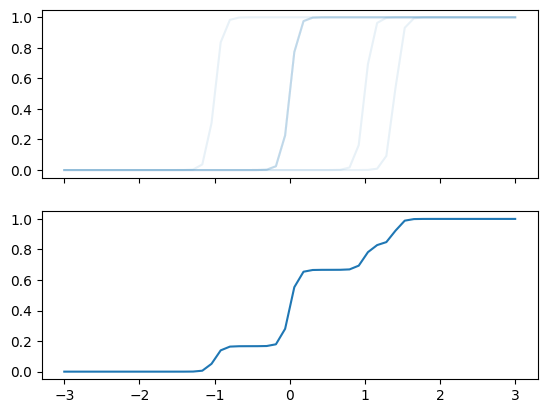

In [30]:
wasserstein_example_sample = np.array([1, 0, -1, 0, 0, 1.4])
example_eval_points = np.linspace(-3, 3, 50)
example_dx = example_eval_points[1] - example_eval_points[0]

fig, ax = plt.subplots(2, 1, sharex = True)
sigmoid = lambda z: 1 / (1 + np.exp(-z))
_k = 20.0

dist = 0
for example_x in wasserstein_example_sample:
    part = sigmoid(_k * (example_eval_points - example_x))
    dist += 1/len(wasserstein_example_sample) * part
    ax[0].plot(example_eval_points, part, alpha = 0.1, color = "tab:blue")
ax[1].plot(example_eval_points, dist)

In [31]:
x_min = -4 
x_max = 4
eval_points = 128
xs = torch.linspace(x_min, x_max, eval_points)
dx = xs[1] - xs[0]
diff = xs.view(-1, 1) - x_t.view(1, -1)
print(diff.shape)
k = 100.0
emp_cdf = torch.mean(torch.sigmoid(k * diff), dim=1)
theo_cdf = 0.5 * (1 + torch.erf((xs - 0) / (1 * np.sqrt(2))))

soft_wasserstein = torch.sum(torch.abs(emp_cdf - theo_cdf) * dx)
print("soft_wasserstein:", soft_wasserstein)

torch.Size([128, 64])
soft_wasserstein: tensor(0.7007)


/var/folders/qy/d4gqcbtd3mb8ywz_m0qm7g440000gn/T/ipykernel_31269/3040572852.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].plot(A[0] * plot_t, A[1] * plot_t, color = "tab:red", label = "Random Direction")


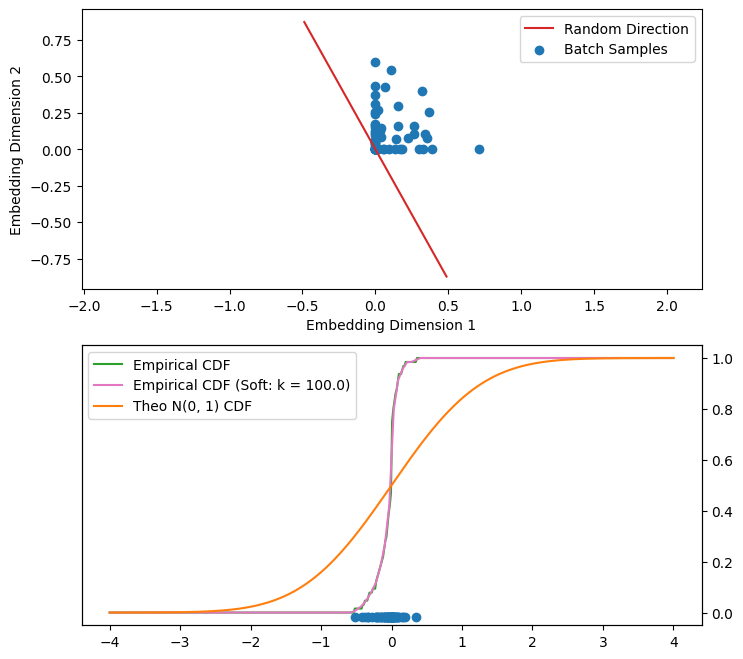

In [32]:
fig, ax = plt.subplots(2, 1, figsize = (8, 8))

plot_t = np.linspace(-1, 1)
ax[0].plot(A[0] * plot_t, A[1] * plot_t, color = "tab:red", label = "Random Direction")
ax[0].scatter(emb[:, 0], emb[:, 1], label = "Batch Samples")
ax[0].set_xlabel("Embedding Dimension 1")
ax[0].set_ylabel("Embedding Dimension 2")
ax[0].set_aspect('equal', adjustable = "datalim")
ax[0].legend()

ax[1].scatter(x_t, 0 * np.ones_like(x_t))
ax[1].set_ylim((0-0.03, 1))
ax[1].set_yticks([])
twinx = ax[1].twinx()

twinx.plot(x_grid, cdf_emp, color = "tab:green", label = "Empirical CDF")
twinx.plot(xs, emp_cdf, color = "tab:pink", label = f"Empirical CDF (Soft: k = {k})")
twinx.plot(x_grid, cdf_theo, color = "tab:orange", label = "Theo N(0, 1) CDF")
twinx.legend()

Training to minimise SIGREG loss

In [34]:
def soft_wasserstein(x_t, device = "cpu"):
    """
    x_t: (B, num_directions)
    """
    x_min = -5 
    x_max = 5
    eval_points = 128
    xs = torch.linspace(x_min, x_max, eval_points, device = device) # shape (eval_points)
    dx = xs[1] - xs[0]

    """
    xs.view(1, 1, -1) # shape (1, 1, eval_points)
    x_t.view(...) # shape (B, num_directions, 1)

    subtraction causes broadcasting in all dimensions
    """
    
    diff = xs.view(1, 1, -1) - x_t.view(x_t.shape[0], x_t.shape[1], 1) # shape (B, num_directions, eval_points)

    k = 100.0 
    emp_cdf = torch.mean(torch.sigmoid(k * diff), dim=0) # shape (num_directions, eval_points)
    theo_cdf = 0.5 * (1 + torch.erf((xs - 0) / (1 * np.sqrt(2)))) # shape (eval_points)
    wasserstein = torch.sum(torch.abs(emp_cdf - theo_cdf) * dx, axis = -1)
    return wasserstein

def SIGREG_loss(emb, device="cpu"):
    """
    emb: (B, D). B samples in batch. Each sample is an embedding within \mathbb{R}^D
    """
    A = torch.randn(emb.size(-1), 256, device = device) # 256 random directions. A: (D, 256)
    A = A.div_(A.norm(p = 2, dim = 0))
    
    x_t = (emb @ A) # x_t: squeeze of (B, D) @ (D, 256) -> (B, 256)
     
    wasserstein = soft_wasserstein(x_t, device)
    loss = wasserstein.mean()
    return loss

def stub_model_1(x: torch.Tensor) -> torch.Tensor:
    """This stub model downprojects (B, D) -> (B, 2)"""
    x_flat = x.view(x.shape[0], -1)    
    return x_flat[:, :32]

emb = stub_model_1(img_aug_example)
print("emb.shape:", emb.shape)
print(SIGREG_loss(emb))


emb.shape: torch.Size([64, 32])
tensor(0.6895)


In [61]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, output_dim=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, stride=1, padding=1)  # (B,32,28,28)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1) # (B,64,14,14)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # (B,128,7,7)
        self.fc = nn.Linear(128*7*7, output_dim)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))  # (B,32,28,28)
        x = F.relu(self.conv2(x))  # (B,64,14,14)
        x = F.relu(self.conv3(x))  # (B,128,7,7)
        x = torch.flatten(x, 1)    # (B, 128*7*7)
        x = self.fc(x)             # (B, output_dim)
        return x

model = SimpleCNNEncoder()
model(img_aug_example)

tensor([[ 0.0289, -0.0277, -0.0030,  ..., -0.0091,  0.0083,  0.0193],
        [ 0.0268, -0.0147, -0.0029,  ..., -0.0041,  0.0114,  0.0305],
        [ 0.0218, -0.0216, -0.0068,  ..., -0.0025,  0.0025,  0.0252],
        ...,
        [ 0.0236, -0.0157, -0.0099,  ..., -0.0021,  0.0085,  0.0204],
        [ 0.0214, -0.0102,  0.0036,  ..., -0.0010,  0.0133,  0.0198],
        [ 0.0199, -0.0232,  0.0057,  ..., -0.0083,  0.0100,  0.0291]],
       grad_fn=<AddmmBackward0>)

In [62]:
trainset = MNIST(root = DATASET_PATH)
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

model = SimpleCNNEncoder().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
model.train()
num_epochs = 3

In [96]:
for epoch in range(num_epochs):
    total_loss = 0.0
    for img_aug, img_orig in trainloader:
        img_aug = img_aug.to(device)
        img_orig = img_orig.to(device)

        z1 = model(img_aug)
        z2 = model(img_orig)

        loss = SIGREG_loss(z1, device)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss / len(trainloader):.4f}")


Epoch 1/3 | Loss: 0.1671
Epoch 2/3 | Loss: 0.1660
Epoch 3/3 | Loss: 0.1648


A tensor([[-0.1259],
        [ 0.3465],
        [-0.1031],
        [ 0.0811],
        [ 0.3637],
        [-0.0789],
        [-0.2732],
        [ 0.1318],
        [ 0.2496],
        [ 0.0803],
        [-0.1289],
        [ 0.3265],
        [ 0.4974],
        [-0.0430],
        [-0.3540],
        [ 0.2232]])


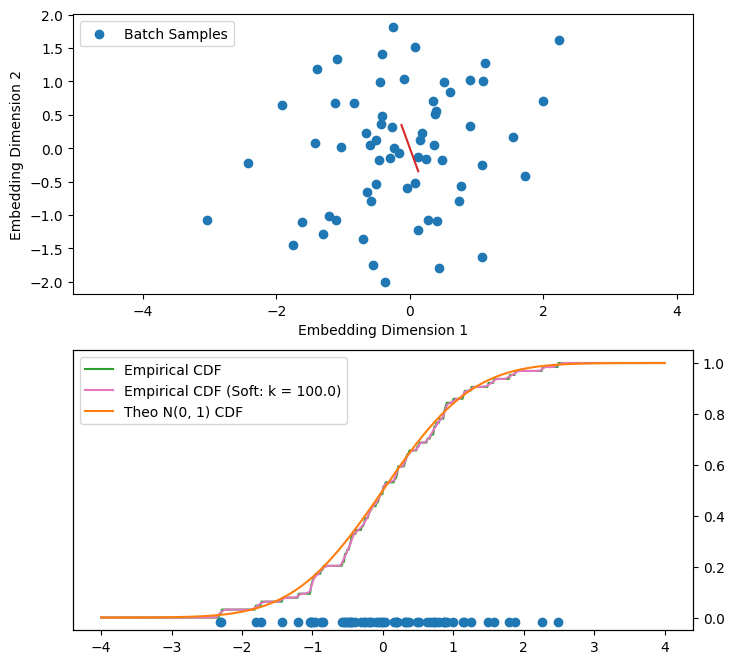

In [97]:
def visualise_guassianness_in_2D(emb):
    A = torch.randn(emb.size(-1), 1)
    A = A.div_(A.norm(p = 2, dim = 0))
    print("A", A)

    x_t = (emb @ A).squeeze(-1)
    x_t_sorted = torch.sort(x_t).values
    x_grid = torch.linspace(-4, 4, 500)
    dx = x_grid[1] - x_grid[0]
    cdf_emp_hard = torch.searchsorted(x_t_sorted, x_grid, right=True) / x_t_sorted.numel()

    x_grid = torch.linspace(-4, 4, 500)
    dx = x_grid[1] - x_grid[0]
    diff = xs.view(-1, 1) - x_t.view(1, -1)
    k = 100.0
    cdf_emp_soft = torch.mean(torch.sigmoid(k * diff), dim = 1)

    cdf_theo = 0.5 * (1 + torch.special.erf((x_grid - 0) / (1 * np.sqrt(2))))


    fig, ax = plt.subplots(2, 1, figsize = (8, 8))
    plot_At = torch.linspace(-1, 1, 100)
    ax[0].plot(A[0] * plot_At, A[1] * plot_At, color = "tab:red")
    ax[0].scatter(emb[:, 0], emb[:, 1], label = "Batch Samples")
    ax[0].set_xlabel("Embedding Dimension 1")
    ax[0].set_ylabel("Embedding Dimension 2")
    ax[0].set_aspect('equal', adjustable = "datalim")
    ax[0].legend()

    ax[1].scatter(x_t, 0 * np.ones_like(x_t))
    ax[1].set_ylim((0-0.03, 1))
    ax[1].set_yticks([])
    twinx = ax[1].twinx()

    twinx.plot(x_grid, cdf_emp_hard, color = "tab:green", label = "Empirical CDF")
    twinx.plot(xs, cdf_emp_soft, color = "tab:pink", label = f"Empirical CDF (Soft: k = {k})")
    twinx.plot(x_grid, cdf_theo, color = "tab:orange", label = "Theo N(0, 1) CDF")
    twinx.legend()

model.eval()
with torch.inference_mode():
    emb = model(img_aug).detach().cpu()
visualise_guassianness_in_2D(emb)